# Low-order GID on the two-sphere

This notebook shows the first two GID levels on `S^2`:

- Level 1 matches linear features and corresponds to vMF mean-direction information.
- Level 2 adds traceless quadratic features and captures axial, antipodal, elliptic, and girdle structure.

The examples are deliberately simple: a concentrated vMF cloud, an antipodal mixture, and a girdle distribution.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## Generate examples and fit level 1/2 projections

The maximum-entropy models are fitted by deterministic Fibonacci quadrature on the sphere.

In [2]:

rng = np.random.default_rng(20260704)
n = 500
w = np.full(n, 1/n)
quad_X, quad_w = src.fibonacci_sphere(7000)

examples = {
    "vMF cloud": src.sample_vmf_s2(n, mu=[0, 0, 1], kappa=8.0, rng=rng),
    "Antipodal mixture": src.sample_antipodal_s2(n, mu=[0, 0, 1], kappa=10.0, rng=rng),
    "Girdle distribution": src.sample_girdle_s2(n, axis=[0, 0, 1], sigma=0.16, rng=rng),
}

rows = []
fits = {}
for name, X in examples.items():
    fit = src.fit_s2_level12(X, w, quad_X, quad_w)
    fits[name] = fit
    r, R = src.mean_resultant(X, w)
    kappa = src.estimate_kappa_s2(R)
    rows.append({
        "Scenario": name,
        "I1": fit["I"][0],
        "I2": fit["I"][1],
        "D2": fit["D"][-1],
        "R": R,
        "kappa_hat": kappa,
        "A_Q": src.frobenius_anisotropy_s2(X, w),
        "Dominant gap": f"I{np.argmax(fit['I']) + 1}",
    })

table = pd.DataFrame(rows)
table.round(3)


,Scenario,I1,I2,D2,R,kappa_hat,A_Q,Dominant gap
0,vMF cloud,1.753,0.006,1.759,0.873,7.848,0.546,I1
1,Antipodal mixture,0.001,1.258,1.259,0.026,0.078,0.589,I2
2,Girdle distribution,0.005,0.807,0.813,0.060,0.180,0.351,I2


The vMF cloud has a large first gap and essentially no residual second gap.  The antipodal and girdle distributions have almost no mean direction, so a vMF summary is close to uniform, but the second gap is large.

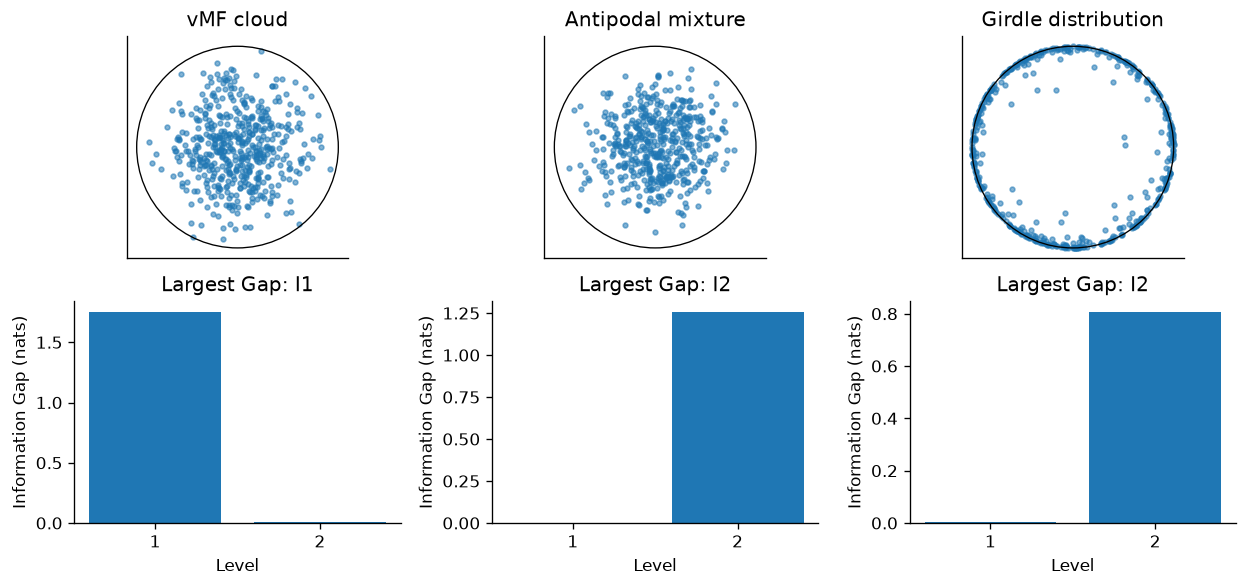

In [3]:

fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.0))
for j, (name, X) in enumerate(examples.items()):
    ax = axes[0, j]
    xx, yy = src.orthographic_project_s2(X)
    ax.scatter(xx, yy, s=8, alpha=0.55)
    ax.set_aspect("equal")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    circle = plt.Circle((0, 0), 1, fill=False, linewidth=0.8)
    ax.add_patch(circle)

    axb = axes[1, j]
    I = fits[name]["I"]
    axb.bar([1, 2], I)
    axb.set_title(f"Largest Gap: I{np.argmax(I)+1}")
    axb.set_xlabel("Level")
    axb.set_xticks([1, 2])
    axb.set_ylabel("Information Gap (nats)")
fig.tight_layout()
plt.show()


## Optional: a tetrahedral example

A symmetric four-mode distribution has little first-order signal and limited second-order signal.  Detecting the remaining structure requires higher harmonic features.  This notebook only fits levels 1 and 2, so the tetrahedral example is shown as a reminder of why higher levels are useful.

In [4]:

X_tet = src.sample_tetrahedral_s2(n, kappa=15.0, rng=rng)
fit_tet = src.fit_s2_level12(X_tet, w, quad_X, quad_w)
r, R = src.mean_resultant(X_tet, w)

pd.DataFrame([{
    "Scenario": "Tetrahedral mixture",
    "I1": fit_tet["I"][0],
    "I2": fit_tet["I"][1],
    "D2": fit_tet["D"][-1],
    "R": R,
    "kappa_hat": src.estimate_kappa_s2(R),
    "A_Q": src.frobenius_anisotropy_s2(X_tet, w),
}]).round(3)


,Scenario,I1,I2,D2,R,kappa_hat,A_Q
0,Tetrahedral mixture,0.001,0.008,0.009,0.028,0.083,0.048
